# Configuración básica (no tocar)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [17]:
x = Variable()

# Implementación de métodos

In [18]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    fa = df.eval(a)
    fb = df.eval(b)

    if fa * fb > 0:
        raise ValueError("La derivada no cambia de signo en [a, b]")

    c = a
    for step in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = df.eval(c)

        if abs(fc) < tol or (b - a) / 2 < tol:
            return c, step

        if fa * fc < 0:
            b = c
        else:
            a = c
            fa = fc

    return c, max_iter


def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    d2f = df.derivative()
    xn = x0

    for step in range(1, max_iter + 1):
        segunda_derivada = d2f.eval(xn)
        if abs(segunda_derivada) < 1e-12:
            raise ValueError("Segunda derivada nula, método no aplicable")

        desplazamiento = df.eval(xn) / segunda_derivada
        xn = xn - desplazamiento

        if abs(desplazamiento) < tol:
            return xn, step

    return xn, max_iter


def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0

    for step in range(1, max_iter + 1):
        siguiente = xn - lr * df.eval(xn)

        if abs(siguiente - xn) < tol:
            return siguiente, step

        xn = siguiente

    return xn, max_iter

### Prueba de métodos

f(x) = x^2 Bisección x = 0.000000 iteraciones = 1
f(x) = x^2 Newton x = 0.000000 iteraciones = 2
f(x) = x^2 Descenso x = 0.000048 iteraciones = 492
f(x) = (x + 0.5)^3 - x - 0.5 Bisección x = 0.077350 iteraciones = 21
f(x) = (x + 0.5)^3 - x - 0.5 Newton x = 0.077350 iteraciones = 6
f(x) = (x + 0.5)^3 - x - 0.5 Descenso x = 0.077378 iteraciones = 278
f(x) = -cos(x) Bisección x = 0.000000 iteraciones = 1
f(x) = -cos(x) Newton x = 0.000000 iteraciones = 5
f(x) = -cos(x) Descenso x = 0.000098 iteraciones = 927


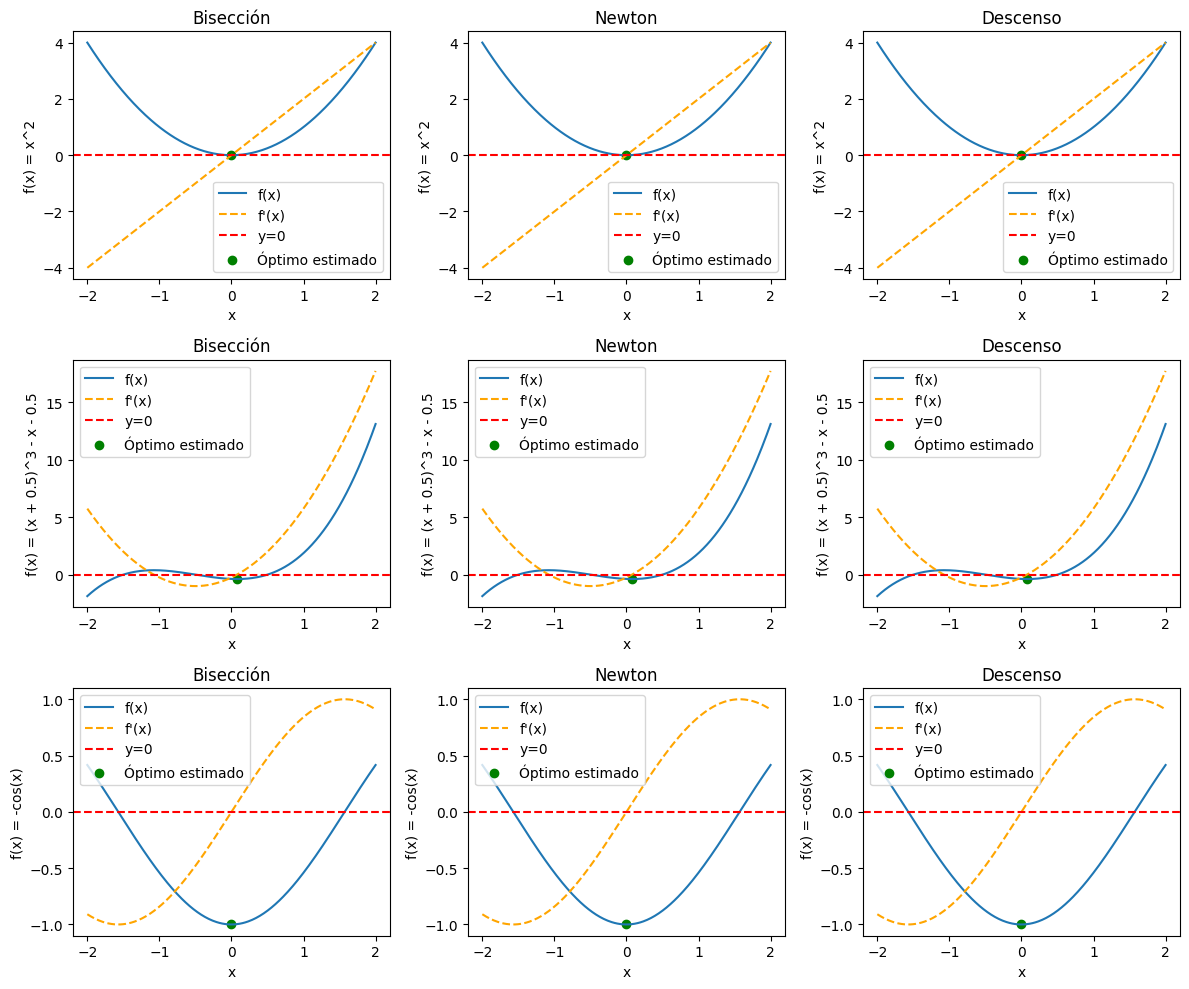

In [20]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)
        print(y_labels[i], titles[j], f"x = {res:.6f}", f"iteraciones = {step}")

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

# Aplicación a función no trivial

In [5]:
f = x**2 + 2*sin(3*x)

In [6]:
# Grafica de la función

In [7]:
# Evaluación de métodos y generación de tablas

# Ajuste de datos

In [8]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

In [9]:
# Genere la función de pérdida

In [10]:
# Optimice la función de pérdida

In [11]:
# Grafique datos y ajuste

# BONUS: